In [38]:

# 1. Import Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 2. Load Dataset (Using Pandas CSV)
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
tre = df['Embarked'].mode()
print(tre)

0    S
Name: Embarked, dtype: object


In [40]:
# =========================================
# Data Visualization I + II (Titanic Dataset)
# =========================================


# 3. Data Preprocessing

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df['Sex'] = df['Sex'].map({'male':0 , 'female' : 1})

# Drop column with too many missing values
df.drop(columns=["Cabin","SibSp"], inplace=True)

# Convert datatype
df["Survived"] = df["Survived"].astype("int64")

# Remove duplicates
pra  =df.drop_duplicates(inplace=True)
pra

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [41]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
# df = pd.get_dummies(data = df , columns=["Embarked"])
df["Embarked"] = df["Embarked"].map({'S':0,'Q':2,'C':1})
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,373450,8.0500,0


In [43]:

# =========================================
# Handle outliers (IQR method for Fare)
# =========================================

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Fare"] = df["Fare"].clip(lower, upper)

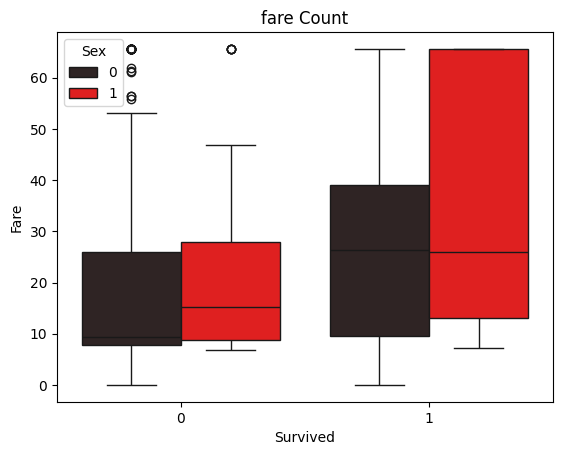

In [48]:
plt.figure()
sns.boxplot(y="Fare", x= "Survived" , data=df , hue= "Sex" ,palette='dark:red')
plt.title("fare Count")
plt.show()

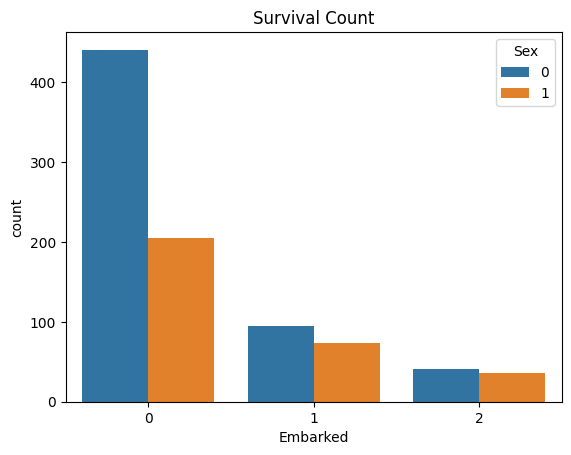

In [45]:
# =========================================
# Data Visualization I
# =========================================

# Survival Count
plt.figure()
sns.countplot(x="Embarked",hue="Sex", data=df)
plt.title("Survival Count")
plt.show()

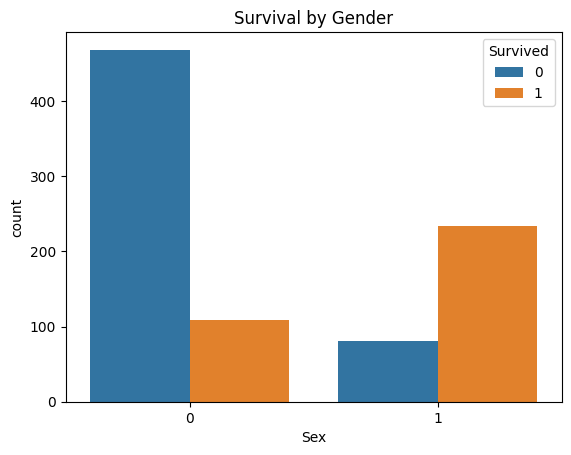

In [53]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

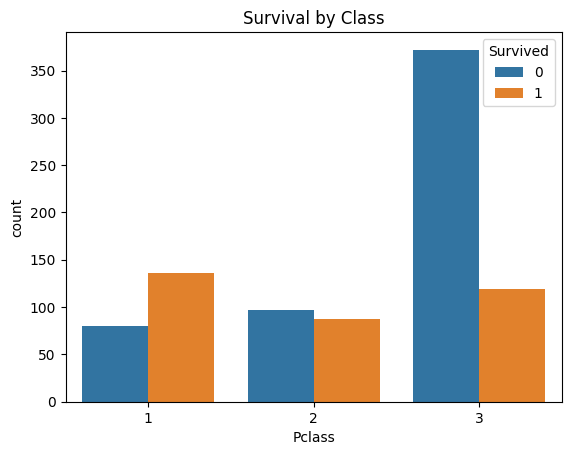

In [54]:

# Survival by Class
plt.figure()
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Class")
plt.show()


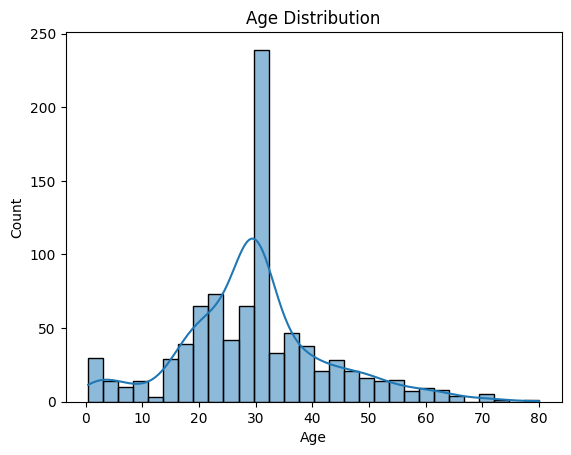

In [23]:
# Age Distribution
plt.figure()
sns.histplot(data = df , x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


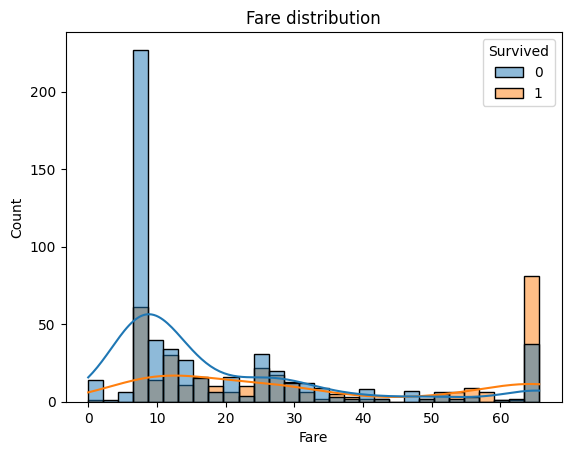

In [107]:
plt.figure()
sns.histplot(x=df["Fare"], hue = df["Survived"] , bins= 30 , kde = True)
plt.title("Fare distribution")
plt.show()

In [62]:

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Age"] = df["Age"].clip(lower, upper)

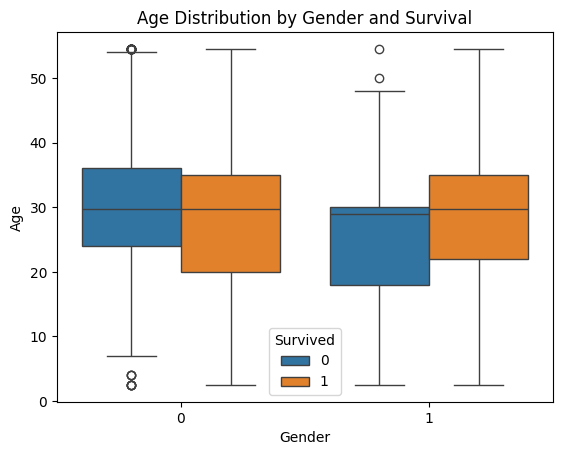

In [65]:
# =========================================
# Data Visualization II
# =========================================

# Box Plot: Age distribution by Gender and Survival
plt.figure()
sns.boxplot(x="Sex", y="Age", hue="Survived", data=df)
plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()


New Age Range: 2.5 to 54.5


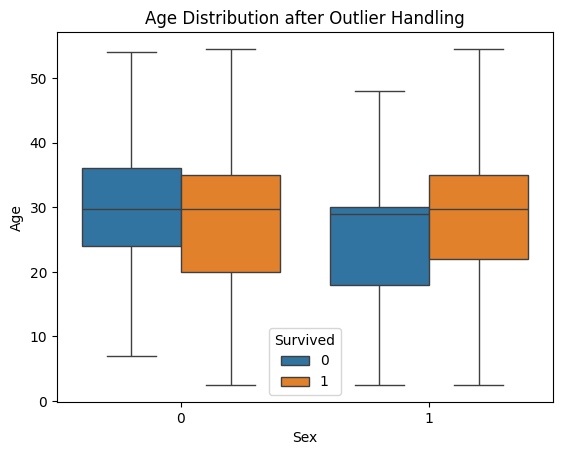

In [66]:
# =========================================
# Handle Outliers (Age)
# =========================================

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping
df["Age"] = df["Age"].clip(lower, upper)

print("New Age Range:", df["Age"].min(), "to", df["Age"].max())

# Boxplot after handling outliers
plt.figure()
sns.boxplot(x="Sex", y="Age", hue="Survived", data=df, showfliers=False)
plt.title("Age Distribution after Outlier Handling")
plt.show()